
Loaded files:
S-M-06-int.csv
S-M-07-int.csv
S-M-11-int.csv
S-M-12-int.csv
S-M-14-int.csv
S-M-27-int.csv

FITTING PARAMETERS USING FIRST 12 POINTS
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         2.1498e+04                                    1.35e+04    
       1              2         6.4529e+03      1.50e+04       2.50e-01       4.30e+04    
       2              3         3.8932e+03      2.56e+03       1.43e-01       4.96e+02    
       3              4         3.1813e+03      7.12e+02       1.46e-01       6.05e+02    
       4              5         3.0748e+03      1.06e+02       3.22e-02       2.26e+02    
       5              6         3.0458e+03      2.90e+01       1.97e-02       8.62e+01    
       6              7         3.0377e+03      8.12e+00       1.13e-02       3.96e+01    
       7              8         3.0370e+03      7.12e-01       6.09e-03       2.48e+01    
       8              9         3.

 recon_index  recon_day recon_date  H_obs  H_recon  H_recon_error  BM_obs  BM_recon  BM_recon_error  BH_obs  BH_recon  BH_recon_error
           1       10.0 2024-04-19 3.4138   1.4293        -1.9845  0.2573    0.0775         -0.1798  6.3289    8.0590          1.7301
           2       19.0 2024-04-28 5.5862   3.7043        -1.8819  0.3995    0.2352         -0.1643  4.0143    6.0461          2.0318
           3       29.0 2024-05-08 8.0000   5.8115        -2.1885  0.5200    0.3939         -0.1261  1.4800    4.1610          2.6810
           4       38.0 2024-05-17 5.4286   8.1048         2.6762  0.3528    0.3947          0.0418  1.0043    2.2196          1.2153
           5       48.0 2024-05-27 2.5714   5.5182         2.9468  0.1672    0.3097          0.1425  0.4757    1.8696          1.3938
           6       57.0 2024-06-05 0.0000   2.6215         2.6215  0.0000    0.2326          0.2326  0.0000    1.3075          1.3075
           7       65.0 2024-06-13 0.3478   0.0113        -0.3

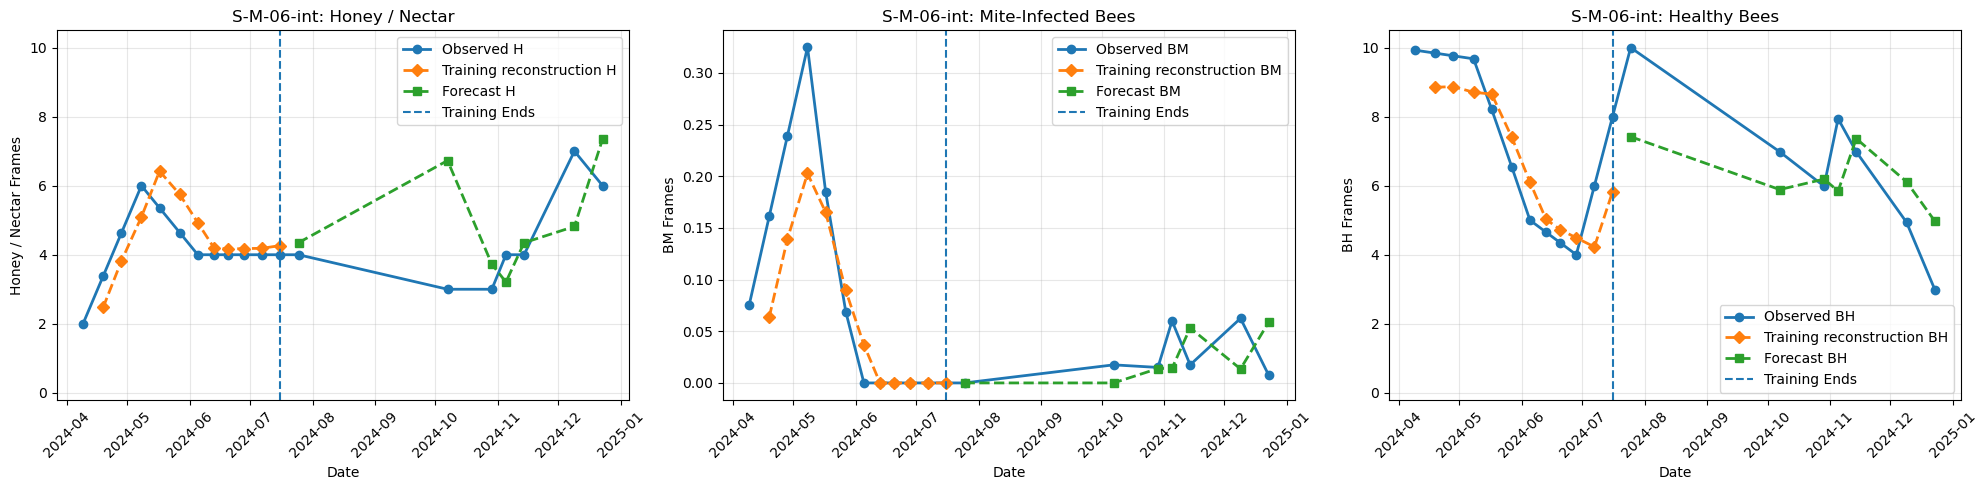

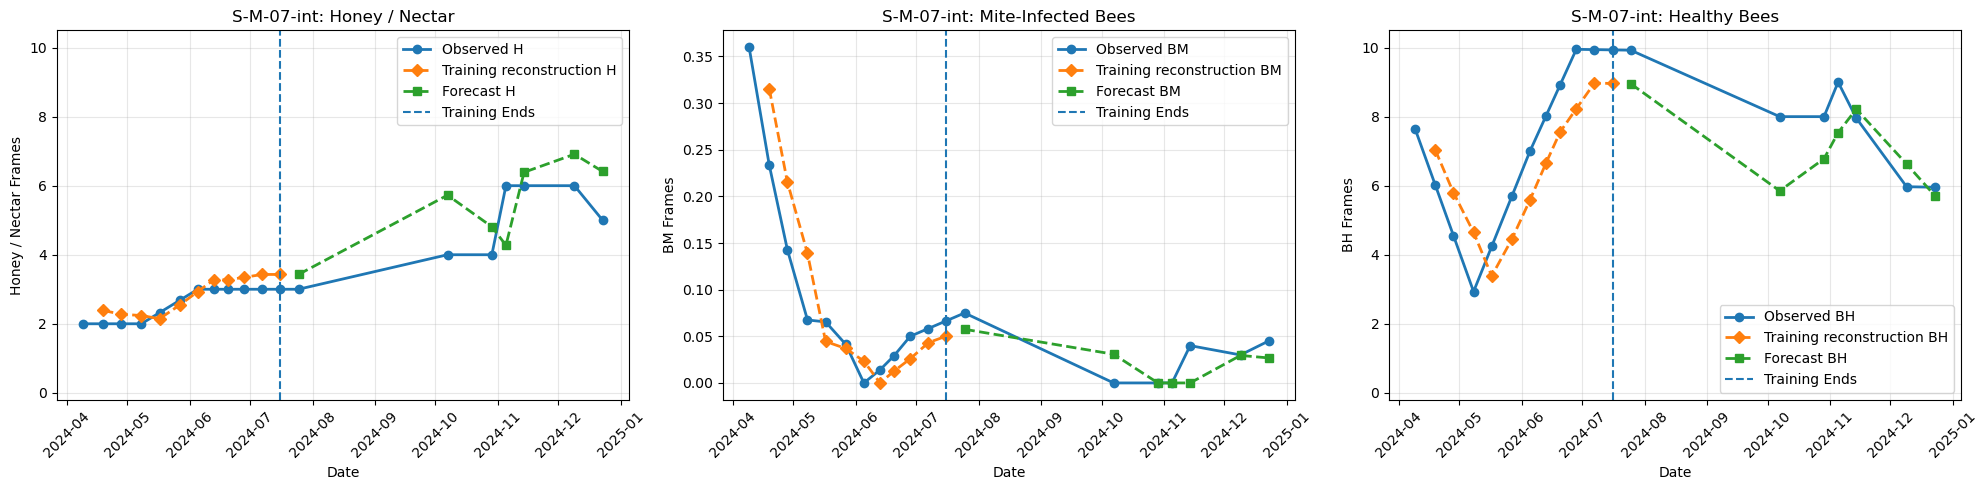

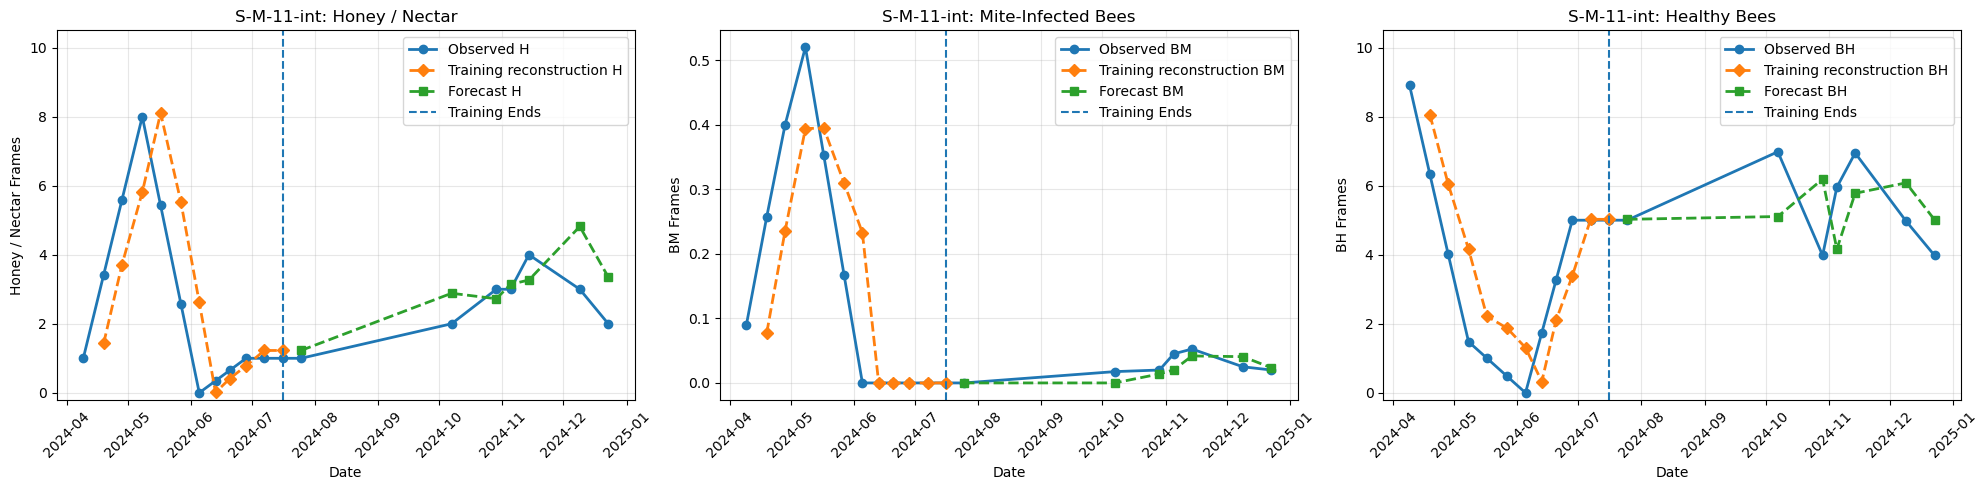

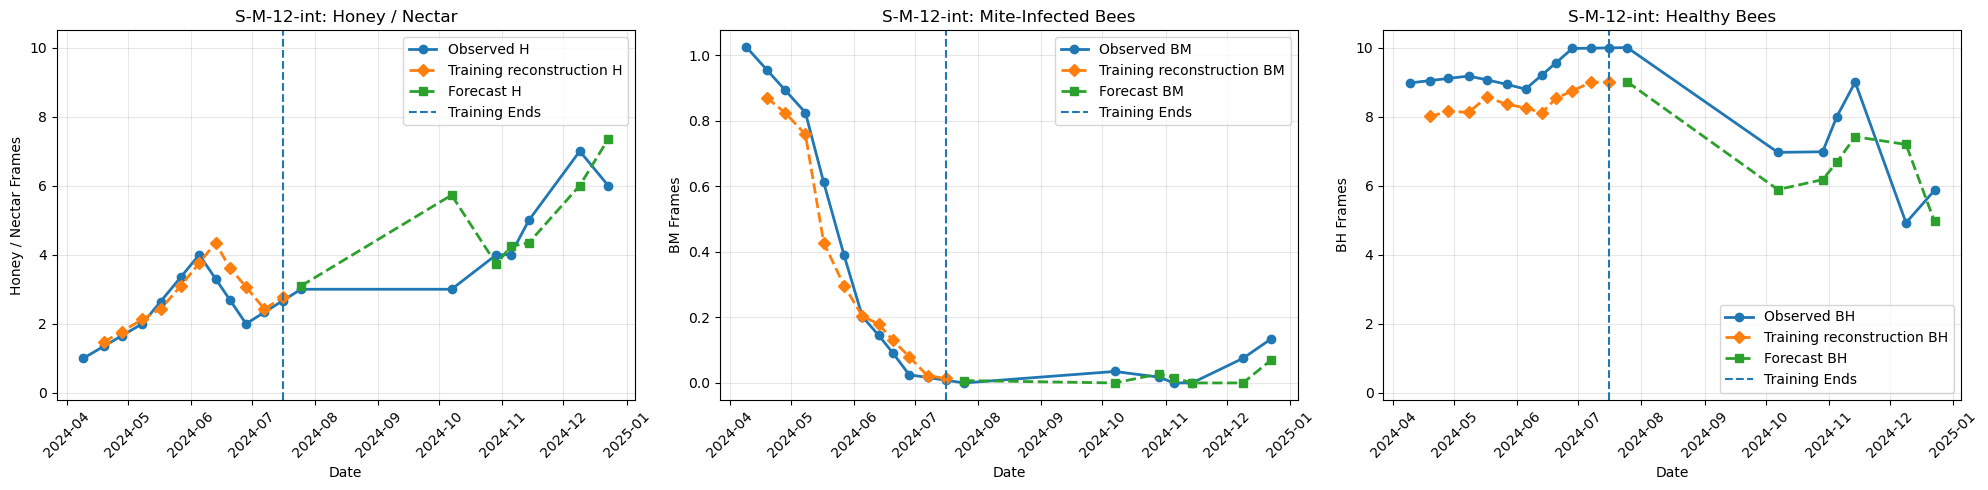

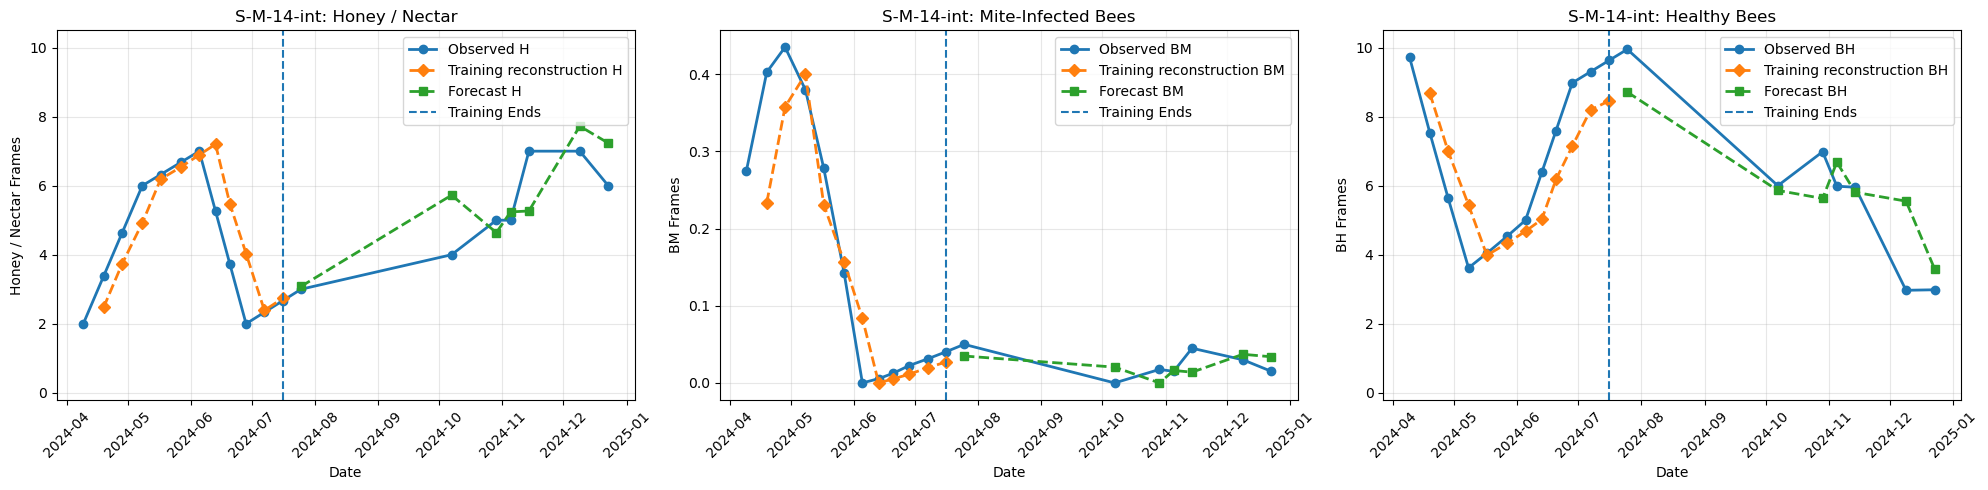

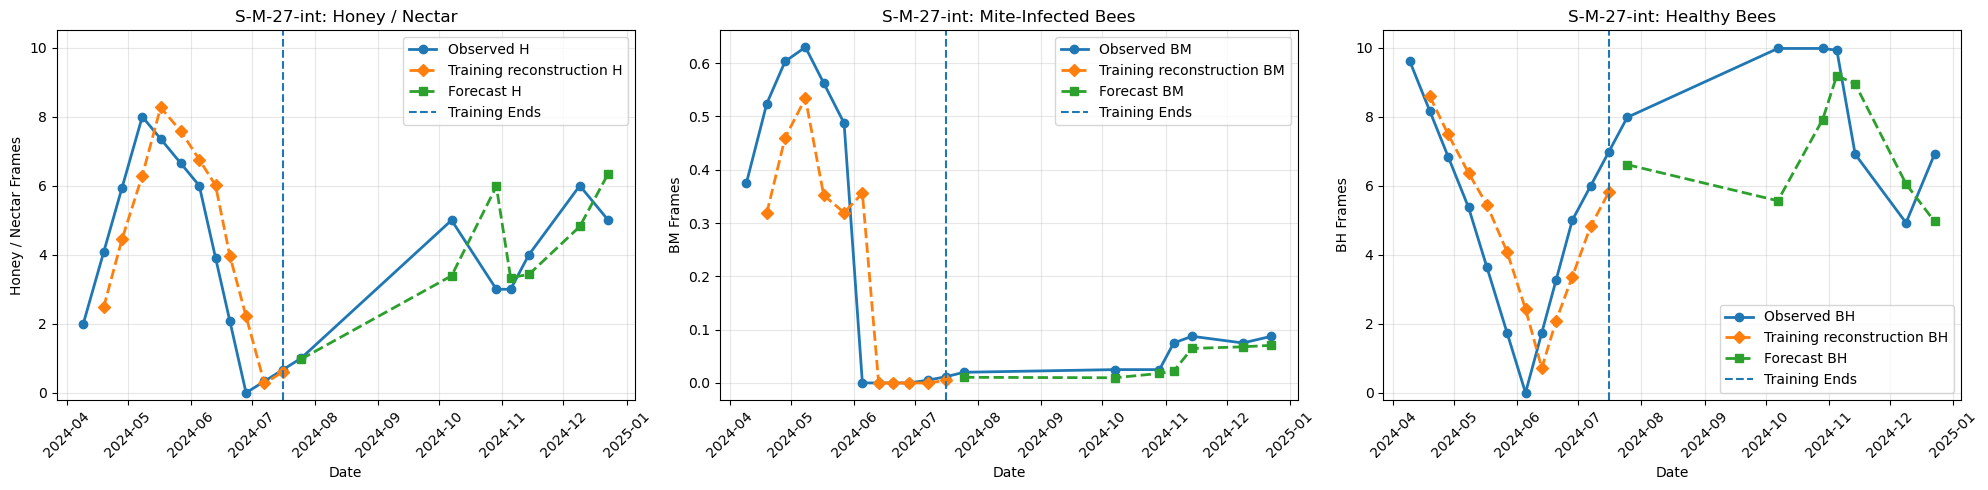

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares
import pandas as pd
import glob
import os

# ============================================================
# SETTINGS
# ============================================================

DATA_FOLDER = r"C:\Bee Temp Data\S-M-train-int"

TRAIN_POINTS = 12
K = 20
EPS = 1e-8

# ============================================================
# LOAD DATA
# ============================================================

csv_files = sorted(glob.glob(os.path.join(DATA_FOLDER, "*.csv")))

print("\nLoaded files:")
for f in csv_files:
    print(os.path.basename(f))

all_hives = []

for file in csv_files:
    data = pd.read_csv(file)
    data["Date"] = pd.to_datetime(data["Date"])

    H_obs = np.array(data["Nectar"], dtype=float)
    BM_obs = np.array(data["Frames Mites"], dtype=float)
    BH_obs = np.array(data["Frame Healthy Bees"], dtype=float)

    hive = {
        "name": os.path.basename(file).replace(".csv", ""),
        "data": data,
        "t": np.array(data["Day"], dtype=float),
        "dates": np.array(data["Date"]),
        "obs": {
            "H": H_obs,
            "BM": BM_obs,
            "BH": BH_obs,
            "B": BM_obs + BH_obs,
            "MTDone": np.array(data["MTDone"], dtype=float),
        },
    }

    all_hives.append(hive)

# ============================================================
# INPUT FUNCTIONS
# ============================================================

def queen_absence_window_func(inspection_times, queen_values, d1=0, d2=2):
    inspection_times = np.asarray(inspection_times, dtype=float)
    queen_values = np.asarray(queen_values, dtype=float)

    windows = []

    for t, q in zip(inspection_times, queen_values):
        if q == 0:
            windows.append((t - d1, t + d2))

    def Q_func(t):
        for start, end in windows:
            if start <= t <= end:
                return 0.0
        return 1.0

    return Q_func


def mite_treatment_func(inspection_times, treatment_values):
    inspection_times = np.asarray(inspection_times, dtype=float)
    treatment_values = np.asarray(treatment_values, dtype=float)

    def uM_func(t):
        idx = np.searchsorted(inspection_times, t, side="right") - 1
        idx = np.clip(idx, 0, len(treatment_values) - 1)
        return float(treatment_values[idx])

    return uM_func

# ============================================================
# ODE MODEL: H, BM, BH
# ============================================================

def ode_rhs(t, y, p, Q_func, uM_func):
    H, BM, BH = y

    B = BM + BH

    Q = float(Q_func(t))
    uM = float(uM_func(t))

    frac_mite = BM / (B + EPS)

    # Capacity factor
    cap = 1.0 / (1.0 + np.exp(K * (H - p["Hmax"])))

    # Fraction of mite-infected bees
    frac_mite = BM / (B + EPS)

    # Honey availability / consumption factor
    e_honey = 1.0 / (1.0 + np.exp(-K * (H - p["H_0"])))

    # Healthy bee death rate depending on honey
    f_honey = 2*p["c7"] + (p["c7"] - 2*p["c7"]) / (
        1.0 + np.exp(-K * (H - p["H_0"]))
    )

    # Mite-infected bee death rate depending on honey
    fM_honey = 2*p["c7"] + (p["c9"] - 2*p["c7"]) / (
        1.0 + np.exp(-K * (H - p["H_0"]))
    )

    # Eq 1: Honey / nectar
    dH = p["c1"] * B * cap - p["c2"] * B * e_honey

    # Eq 2: Mite-infected adult bees
    dBM = (
        p["c6"] * Q * frac_mite * cap * e_honey
        - BM * fM_honey
        - p["c8"] * uM * BM
    )

    # Eq 3: Healthy adult bees
    dBH = (
        p["c6"] * Q * (1.0 - frac_mite) * cap * e_honey
        - BH * f_honey
        + p["c8"] * uM * BM
    )

    return [dH, dBM, dBH]

# ============================================================
# SOLVER
# ============================================================

def simulate_model(t_points, y0, params, Q_func, uM_func):
    t_points = np.asarray(t_points, dtype=float)

    if len(t_points) < 2:
        return np.array([[y0[0]], [y0[1]], [y0[2]]])

    sol = solve_ivp(
        fun=lambda t, y: ode_rhs(t, y, params, Q_func, uM_func),
        t_span=(t_points[0], t_points[-1]),
        y0=np.asarray(y0, dtype=float),
        t_eval=t_points,
        method="RK45",
        rtol=1e-4,
        atol=1e-6,
    )

    if not sol.success:
        raise RuntimeError(sol.message)

    return np.maximum(sol.y, 0.0)

# ============================================================
# PARAMETERS
# ============================================================

FIT_KEYS = ["c1", "c6", "c7", "c8", "c9"]

fixed_params = {
    "c2": 0.0122,
    "Hmax": 10.0,
    "H_0": 0.01,
}

init_guess = {
    "c1": 0.0123,
    "c6": 0.30,
    "c7": 0.05,
    "c8": 0.20,
    "c9": 0.20,
}

lower_bounds = {
    "c1": 0.0123,
    "c6": 0.0001,
    "c7": 0.01,
    "c8": 0.0,
    "c9": 0.03,
}

upper_bounds = {
    "c1": 0.0556,
    "c6": 0.571,
    "c7": 0.08,
    "c7p": 0.24,
    "c8": 1.0,
    "c9": 0.50,
}

weights = {
    "H": 1.0,
    "BM": 0.01,
    "BH": 1.0,
}

# ============================================================
# PACK / UNPACK
# ============================================================

def pack_theta(p):
    return np.array([p[k] for k in FIT_KEYS], dtype=float)


def unpack_theta(theta):
    p = fixed_params.copy()
    for i, key in enumerate(FIT_KEYS):
        p[key] = theta[i]
    return p

# ============================================================
# PARAMETER FITTING
# Use previous observed point as IC:
# 0 -> 1, 1 -> 2, ..., TRAIN_POINTS-2 -> TRAIN_POINTS-1
# ============================================================

def global_residuals(theta):
    try:
        params = unpack_theta(theta)
        residuals = []

        for hive in all_hives:
            t_all = hive["t"]

            obsH = hive["obs"]["H"]
            obsBM = hive["obs"]["BM"]
            obsBH = hive["obs"]["BH"]

            if len(t_all) < TRAIN_POINTS:
                continue

            Q_func = queen_absence_window_func(
                hive["data"]["Day"],
                hive["data"]["Queen"],
            )

            uM_func = mite_treatment_func(
                hive["data"]["Day"],
                hive["data"]["MTDone"],
            )

            for target_idx in range(1, TRAIN_POINTS):

                ic_idx = target_idx - 1

                y0 = [
                    obsH[ic_idx],
                    obsBM[ic_idx],
                    obsBH[ic_idx],
                ]

                t_sim = np.array([
                    t_all[ic_idx],
                    t_all[target_idx],
                ])

                Y = simulate_model(
                    t_sim,
                    y0,
                    params,
                    Q_func,
                    uM_func,
                )

                H_pred = Y[0][-1]
                BM_pred = Y[1][-1]
                BH_pred = Y[2][-1]

                residuals.append((H_pred - obsH[target_idx]) / weights["H"])
                residuals.append((BM_pred - obsBM[target_idx]) / weights["BM"])
                residuals.append((BH_pred - obsBH[target_idx]) / weights["BH"])

        if len(residuals) == 0:
            return 1e6 * np.ones(100)

        return np.array(residuals)

    except Exception as e:
        print("Residual error:", e)
        return 1e6 * np.ones(100)

# ============================================================
# FIT PARAMETERS ONCE
# ============================================================

print("\n" + "=" * 80)
print(f"FITTING PARAMETERS USING FIRST {TRAIN_POINTS} POINTS")
print("=" * 80)

x0 = pack_theta(init_guess)

lb = np.array([lower_bounds[k] for k in FIT_KEYS], dtype=float)
ub = np.array([upper_bounds[k] for k in FIT_KEYS], dtype=float)

fit_result = least_squares(
    fun=global_residuals,
    x0=x0,
    bounds=(lb, ub),
    method="trf",
    max_nfev=5000,
    verbose=2,
)

params_hat = unpack_theta(fit_result.x)

print("\nEstimated parameters:")
for k in FIT_KEYS:
    print(f"{k} = {params_hat[k]:.8f}")
print(f"c2 = {params_hat['c2']:.8f}")
print(f"Training cost = {fit_result.cost:.6f}")

# ============================================================
# TRAINING RECONSTRUCTION
# Previous observed point reconstructs next training point
# ============================================================

training_recon_records = {}

for hive in all_hives:
    name = hive["name"]

    t_all = hive["t"]
    dates = hive["dates"]

    obsH = hive["obs"]["H"]
    obsBM = hive["obs"]["BM"]
    obsBH = hive["obs"]["BH"]

    Q_func = queen_absence_window_func(
        hive["data"]["Day"],
        hive["data"]["Queen"],
    )

    uM_func = mite_treatment_func(
        hive["data"]["Day"],
        hive["data"]["MTDone"],
    )

    records = []

    max_train_idx = min(TRAIN_POINTS, len(t_all))

    for recon_idx in range(1, max_train_idx):

        ic_idx = recon_idx - 1

        y0 = [
            obsH[ic_idx],
            obsBM[ic_idx],
            obsBH[ic_idx],
        ]

        t_recon = np.array([
            t_all[ic_idx],
            t_all[recon_idx],
        ])

        Y = simulate_model(
            t_recon,
            y0,
            params_hat,
            Q_func,
            uM_func,
        )

        H_recon = Y[0][-1]
        BM_recon = Y[1][-1]
        BH_recon = Y[2][-1]

        records.append({
            "recon_index": recon_idx,
            "recon_day": t_all[recon_idx],
            "recon_date": dates[recon_idx],

            "H_obs": obsH[recon_idx],
            "H_recon": H_recon,
            "H_recon_error": H_recon - obsH[recon_idx],

            "BM_obs": obsBM[recon_idx],
            "BM_recon": BM_recon,
            "BM_recon_error": BM_recon - obsBM[recon_idx],

            "BH_obs": obsBH[recon_idx],
            "BH_recon": BH_recon,
            "BH_recon_error": BH_recon - obsBH[recon_idx],
        })

    training_recon_records[name] = pd.DataFrame(records)

# ============================================================
# FORECASTING AFTER TRAINING
# Previous observed point forecasts next point
# First forecast: TRAIN_POINTS-1 -> TRAIN_POINTS
# ============================================================

forecast_records = {}

for hive in all_hives:
    name = hive["name"]

    t_all = hive["t"]
    dates = hive["dates"]

    obsH = hive["obs"]["H"]
    obsBM = hive["obs"]["BM"]
    obsBH = hive["obs"]["BH"]

    Q_func = queen_absence_window_func(
        hive["data"]["Day"],
        hive["data"]["Queen"],
    )

    uM_func = mite_treatment_func(
        hive["data"]["Day"],
        hive["data"]["MTDone"],
    )

    records = []

    for forecast_idx in range(TRAIN_POINTS, len(t_all)):

        ic_idx = forecast_idx - 1

        y0 = [
            obsH[ic_idx],
            obsBM[ic_idx],
            obsBH[ic_idx],
        ]

        t_forecast = np.array([
            t_all[ic_idx],
            t_all[forecast_idx],
        ])

        Y = simulate_model(
            t_forecast,
            y0,
            params_hat,
            Q_func,
            uM_func,
        )

        H_forecast = Y[0][-1]
        BM_forecast = Y[1][-1]
        BH_forecast = Y[2][-1]

        records.append({
            "forecast_index": forecast_idx,
            "forecast_day": t_all[forecast_idx],
            "forecast_date": dates[forecast_idx],

            "H_obs": obsH[forecast_idx],
            "H_forecast": H_forecast,
            "H_error": H_forecast - obsH[forecast_idx],

            "BM_obs": obsBM[forecast_idx],
            "BM_forecast": BM_forecast,
            "BM_error": BM_forecast - obsBM[forecast_idx],

            "BH_obs": obsBH[forecast_idx],
            "BH_forecast": BH_forecast,
            "BH_error": BH_forecast - obsBH[forecast_idx],
        })

    forecast_records[name] = pd.DataFrame(records)

# ============================================================
# PRINT RESULTS
# ============================================================

for hive in all_hives:
    name = hive["name"]

    df_recon = training_recon_records[name]
    df_forecast = forecast_records[name]

    print("\n" + "=" * 80)
    print(f"RESULTS: {name}")
    print("=" * 80)

    if not df_recon.empty:
        print("\nTraining reconstruction:")
        print(df_recon.round(4).to_string(index=False))

        print("\nTraining reconstruction RMSE:")
        print(f"H  RMSE = {np.sqrt(np.mean(df_recon['H_recon_error'] ** 2)):.4f}")
        print(f"BM RMSE = {np.sqrt(np.mean(df_recon['BM_recon_error'] ** 2)):.4f}")
        print(f"BH RMSE = {np.sqrt(np.mean(df_recon['BH_recon_error'] ** 2)):.4f}")

    if not df_forecast.empty:
        print("\nForecasting:")
        print(df_forecast.round(4).to_string(index=False))

        print("\nForecast RMSE:")
        print(f"H  RMSE = {np.sqrt(np.mean(df_forecast['H_error'] ** 2)):.4f}")
        print(f"BM RMSE = {np.sqrt(np.mean(df_forecast['BM_error'] ** 2)):.4f}")
        print(f"BH RMSE = {np.sqrt(np.mean(df_forecast['BH_error'] ** 2)):.4f}")

# ============================================================
# PLOTS: OBSERVED + TRAINING RECONSTRUCTION + FORECASTING
# ============================================================

for hive in all_hives:
    name = hive["name"]

    dates = hive["dates"]

    obsH = hive["obs"]["H"]
    obsBM = hive["obs"]["BM"]
    obsBH = hive["obs"]["BH"]

    df_recon = training_recon_records[name]
    df_forecast = forecast_records[name]

    fig, axs = plt.subplots(1, 3, figsize=(20, 5))

    # Honey
    axs[0].plot(dates, obsH, "o-", label="Observed H", linewidth=2)

    if not df_recon.empty:
        axs[0].plot(
            df_recon["recon_date"],
            df_recon["H_recon"],
            "D--",
            label="Training reconstruction H",
            linewidth=2,
        )

    if not df_forecast.empty:
        axs[0].plot(
            df_forecast["forecast_date"],
            df_forecast["H_forecast"],
            "s--",
            label="Forecast H",
            linewidth=2,
        )

    axs[0].axvline(
        x=dates[TRAIN_POINTS - 1],
        linestyle="--",
        linewidth=1.5,
        label="Training Ends",
    )

    axs[0].set_title(f"{name}: Honey / Nectar")
    axs[0].set_xlabel("Date")
    axs[0].set_ylabel("Honey / Nectar Frames")
    axs[0].set_ylim(-0.2, 10.5)
    axs[0].grid(alpha=0.3)
    axs[0].legend()
    axs[0].tick_params(axis="x", rotation=45)

    # BM
    axs[1].plot(dates, obsBM, "o-", label="Observed BM", linewidth=2)

    if not df_recon.empty:
        axs[1].plot(
            df_recon["recon_date"],
            df_recon["BM_recon"],
            "D--",
            label="Training reconstruction BM",
            linewidth=2,
        )

    if not df_forecast.empty:
        axs[1].plot(
            df_forecast["forecast_date"],
            df_forecast["BM_forecast"],
            "s--",
            label="Forecast BM",
            linewidth=2,
        )

    axs[1].axvline(
        x=dates[TRAIN_POINTS - 1],
        linestyle="--",
        linewidth=1.5,
        label="Training Ends",
    )

    axs[1].set_title(f"{name}: Mite-Infected Bees")
    axs[1].set_xlabel("Date")
    axs[1].set_ylabel("BM Frames")
    axs[1].grid(alpha=0.3)
    axs[1].legend()
    axs[1].tick_params(axis="x", rotation=45)

    # BH
    axs[2].plot(dates, obsBH, "o-", label="Observed BH", linewidth=2)

    if not df_recon.empty:
        axs[2].plot(
            df_recon["recon_date"],
            df_recon["BH_recon"],
            "D--",
            label="Training reconstruction BH",
            linewidth=2,
        )

    if not df_forecast.empty:
        axs[2].plot(
            df_forecast["forecast_date"],
            df_forecast["BH_forecast"],
            "s--",
            label="Forecast BH",
            linewidth=2,
        )

    axs[2].axvline(
        x=dates[TRAIN_POINTS - 1],
        linestyle="--",
        linewidth=1.5,
        label="Training Ends",
    )

    axs[2].set_title(f"{name}: Healthy Bees")
    axs[2].set_xlabel("Date")
    axs[2].set_ylabel("BH Frames")
    axs[2].set_ylim(-0.2, 10.5)
    axs[2].grid(alpha=0.3)
    axs[2].legend()
    axs[2].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()


Loaded files:
24M1.csv
24M10.csv
24M3.csv
24M5.csv
24M7.csv
24M9.csv


C:\Users\mhoss\AppData\Local\Temp\ipykernel_27700\1521816417.py:47: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data["Date"] = pd.to_datetime(data["Date"])
C:\Users\mhoss\AppData\Local\Temp\ipykernel_27700\1521816417.py:47: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data["Date"] = pd.to_datetime(data["Date"])
C:\Users\mhoss\AppData\Local\Temp\ipykernel_27700\1521816417.py:47: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data["Date"] = pd.to_datetime(data["Date"])
C:\Users\mhoss\AppData\Local\Temp\ipykernel_27700\1521816417.py:47: UserWarning: Could not infer format, s


ONE-DAY-AHEAD FORECAST RESULTS: 24M1
 from_index  forecast_index  from_day  forecast_day forecast_date  H_obs  H_forecast  H_error  BM_obs  BM_forecast  BM_error  BH_obs  BH_forecast  BH_error
          0               1       0.0          21.0    2024-07-29    2.0      5.6122   3.6122  0.0000       0.0000    0.0000  6.0000       5.6422   -0.3578
          1               2      21.0          43.0    2024-08-20    2.0      2.6405   0.6405  0.0000       0.0000    0.0000  7.0000       5.6294   -1.3706
          2               3      43.0          65.0    2024-09-11    3.0      2.7253  -0.2747  0.0000       0.0000    0.0000  8.0000       6.2050   -1.7950
          3               4      65.0          84.0    2024-09-30    3.0      3.7071   0.7071  0.0000       0.0000    0.0000  4.0000       6.9100    2.9100
          4               5      84.0         113.0    2024-10-29    5.0      3.6300  -1.3700  0.0161       0.0000   -0.0161  4.9839       4.5826   -0.4013
          5               

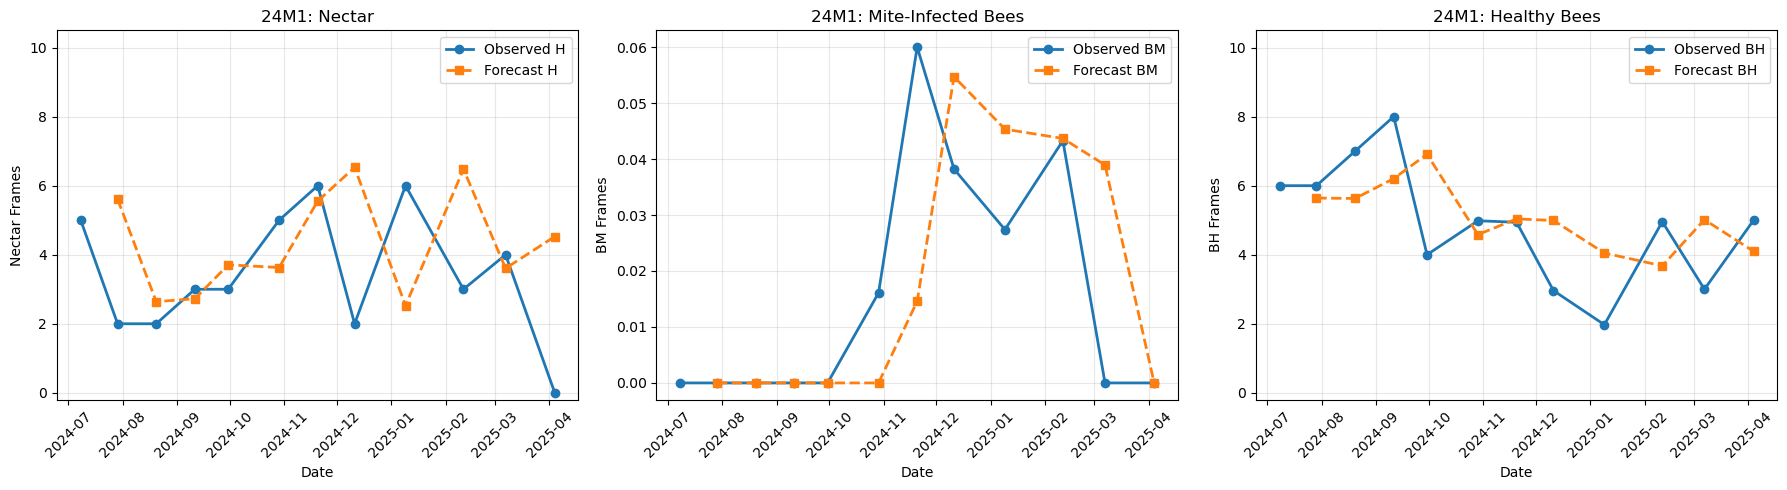

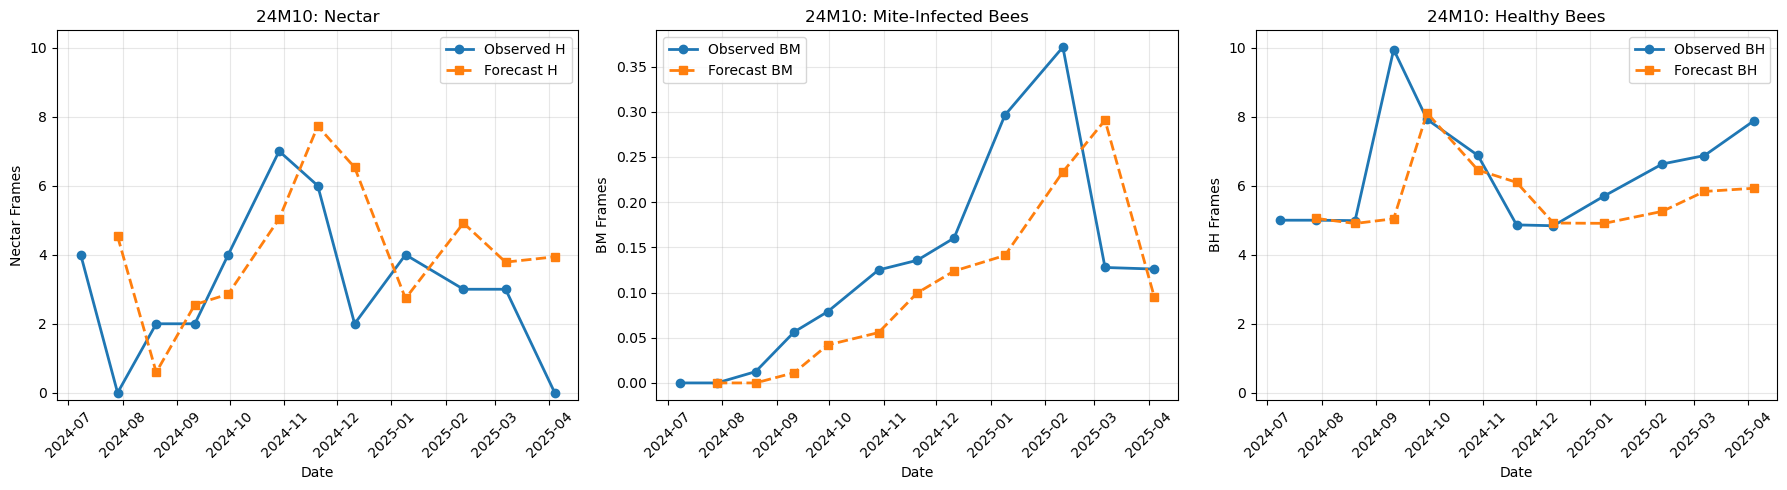

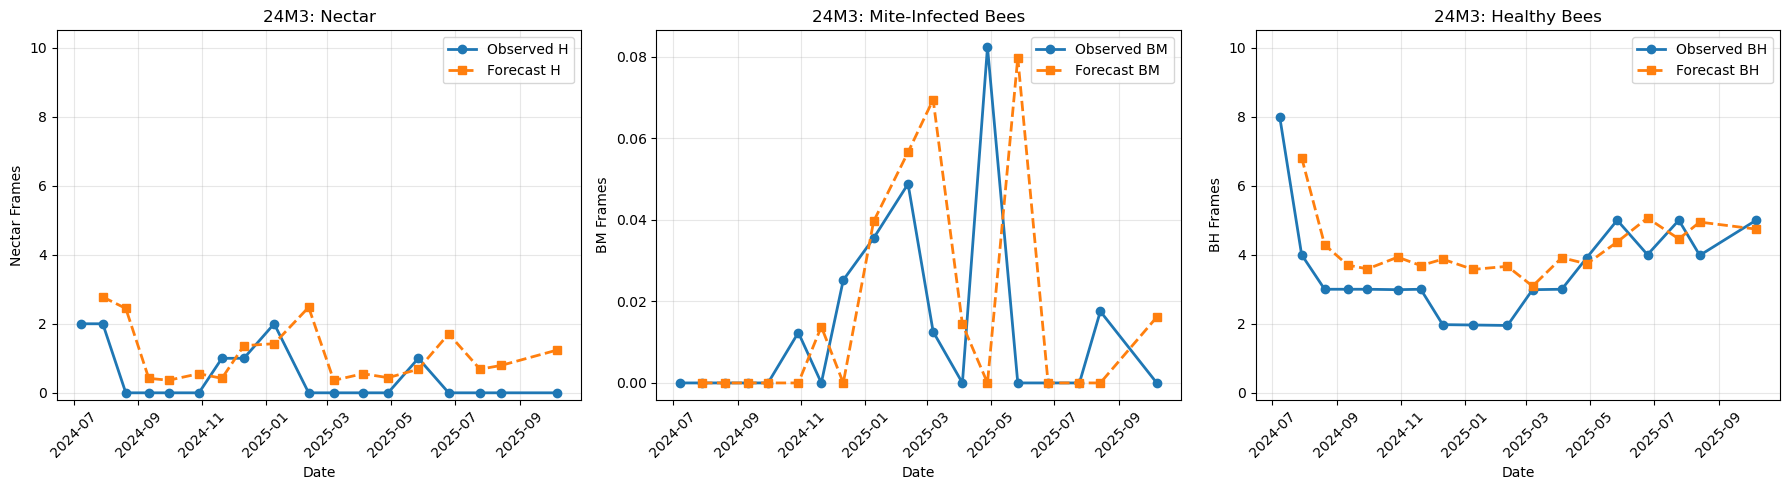

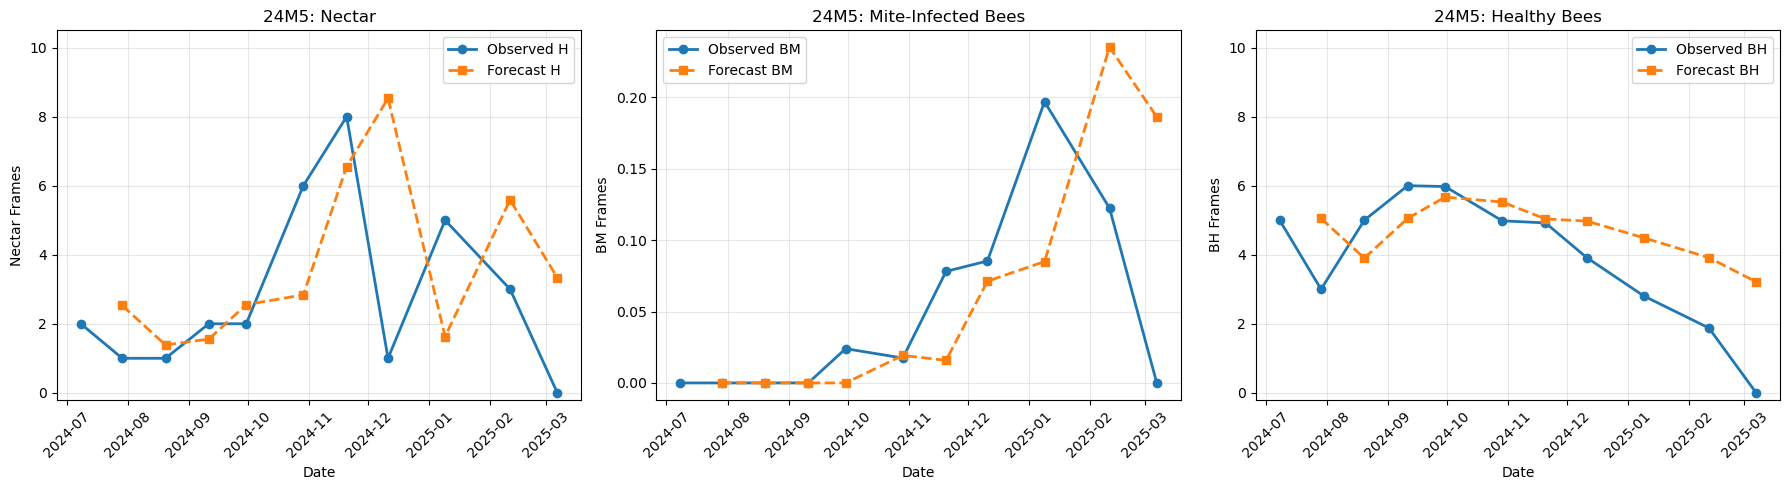

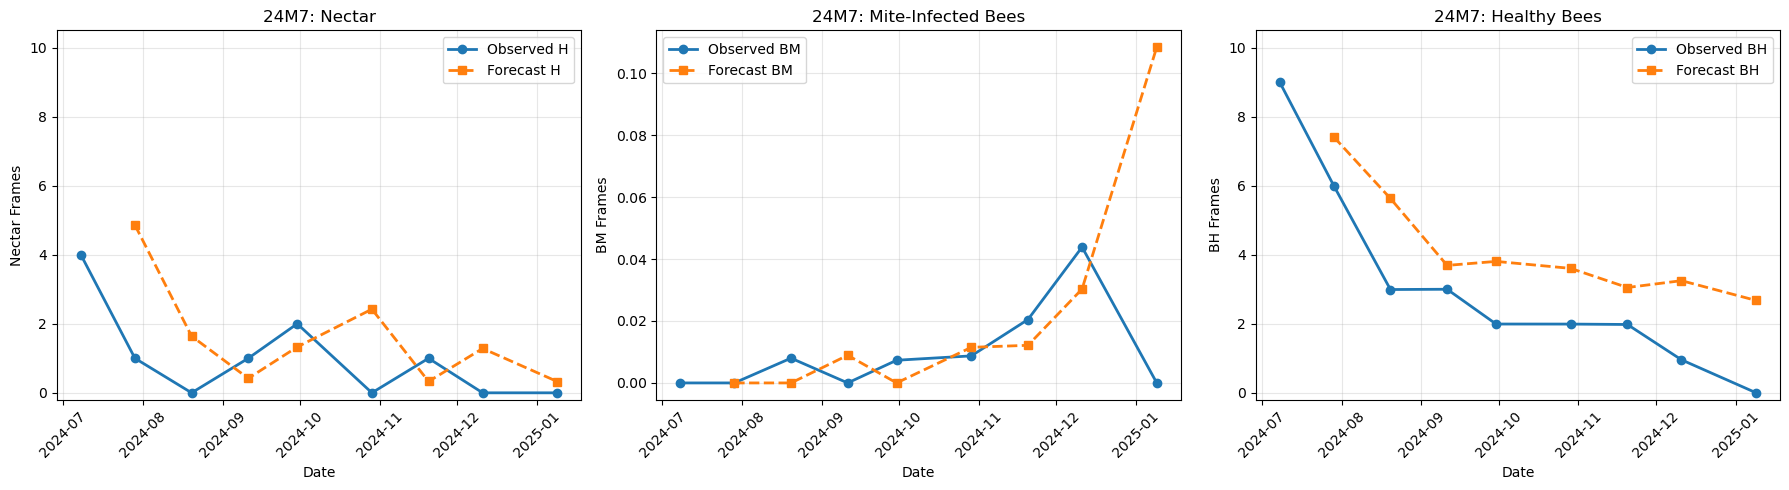

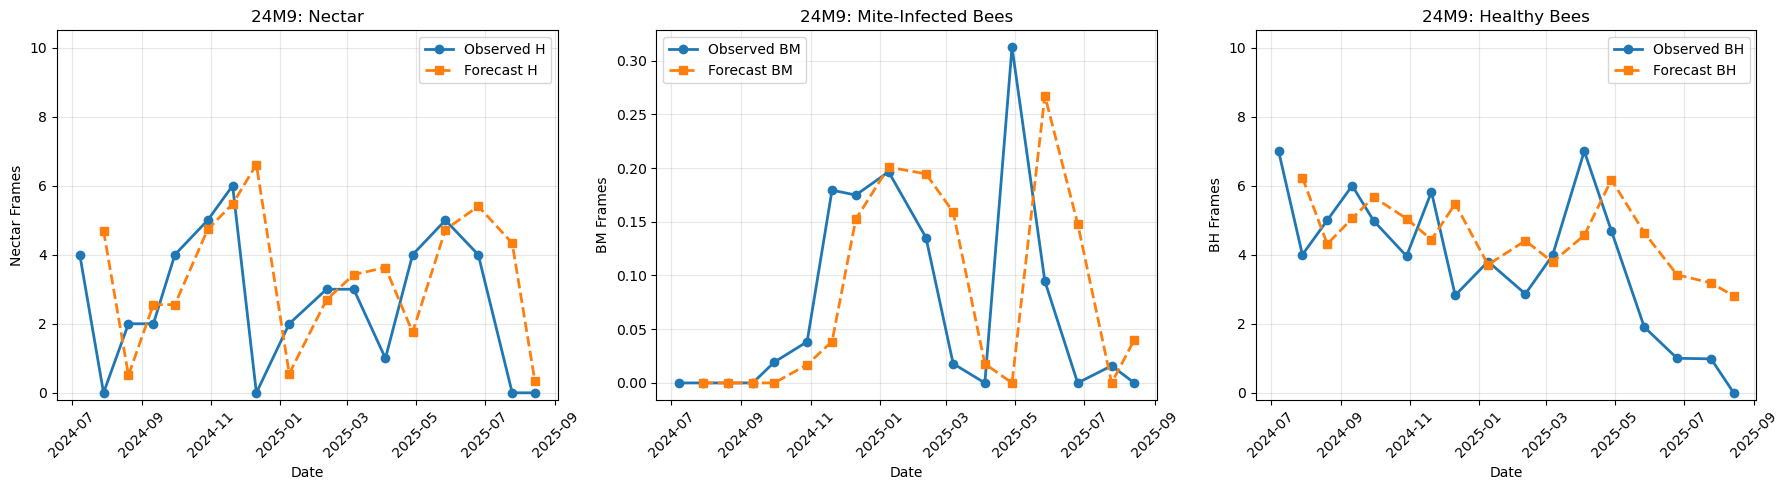

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import pandas as pd
import glob
import os

# ============================================================
# SETTINGS
# ============================================================

DATA_FOLDER = r"C:\Bee Temp Data\24"   # <-- change to new dataset folder

K = 20
EPS = 1e-8

# ============================================================
# USE ESTIMATED PARAMETERS FROM TRAINING DATA
# Replace these values with your estimated parameters
# ============================================================

params_hat = {
    "c1": 0.01722121,
    "c2": 0.01220000,
    "c6":  0.12869423,
    "c7": 0.02510308,
    "c8": 0.05648059,
    "c9": 0.03000010,
    "Hmax": 10.00000000,
    "H_0": 0.01000000,
}

# ============================================================
# LOAD ALL HIVE FILES
# ============================================================

csv_files = sorted(glob.glob(os.path.join(DATA_FOLDER, "*.csv")))

print("\nLoaded files:")
for f in csv_files:
    print(os.path.basename(f))

all_hives = []

for file in csv_files:
    data = pd.read_csv(file)
    data["Date"] = pd.to_datetime(data["Date"])

    H_obs = np.array(data["Nectar"], dtype=float)
    BH_obs = np.array(data["Frame Healthy Bees"], dtype=float)
    BM_obs = np.array(data["Frames Mites"], dtype=float)
    B_obs = BM_obs + BH_obs

    hive = {
        "name": os.path.basename(file).replace(".csv", ""),
        "data": data,
        "t": np.array(data["Day"], dtype=float),
        "dates": np.array(data["Date"]),
        "obs": {
            "H": H_obs,
            "BM": BM_obs,
            "BH": BH_obs,
            "B": B_obs,
            "MTDone": np.array(data["MTDone"], dtype=float),
        },
    }

    all_hives.append(hive)

# ============================================================
# QUEEN FUNCTION
# ============================================================

def queen_absence_window_func(inspection_times, queen_values, d1=0, d2=2):
    inspection_times = np.asarray(inspection_times, dtype=float)
    queen_values = np.asarray(queen_values, dtype=float)

    windows = []

    for t, q in zip(inspection_times, queen_values):
        if q == 0:
            windows.append((t - d1, t + d2))

    def Q_func(t):
        for start, end in windows:
            if start <= t <= end:
                return 0.0
        return 1.0

    return Q_func

# ============================================================
# MITE TREATMENT FUNCTION
# ============================================================

def mite_treatment_func(inspection_times, treatment_values):
    inspection_times = np.asarray(inspection_times, dtype=float)
    treatment_values = np.asarray(treatment_values, dtype=float)

    def uM_func(t):
        idx = np.searchsorted(inspection_times, t, side="right") - 1

        if idx < 0:
            return treatment_values[0]

        return treatment_values[idx]

    return uM_func

# ============================================================
# ODE MODEL: H, BM, BH
# ============================================================

def ode_rhs(t, y, p, Q_func, uM_func):
    H, BM, BH = y

    B = BM + BH

    Q = float(Q_func(t))
    uM = float(uM_func(t))

    frac_mite = BM / (B + EPS)

    # Capacity factor
    cap = 1.0 / (1.0 + np.exp(K * (H - p["Hmax"])))

    # Fraction of mite-infected bees
    frac_mite = BM / (B + EPS)

    # Honey availability / consumption factor
    e_honey = 1.0 / (1.0 + np.exp(-K * (H - p["H_0"])))

    # Healthy bee death rate depending on honey
    f_honey = 2*p["c7"] + (p["c7"] - 2*p["c7"]) / (
        1.0 + np.exp(-K * (H - p["H_0"]))
    )

    # Mite-infected bee death rate depending on honey
    fM_honey = 2*p["c7"] + (p["c9"] - 2*p["c7"]) / (
        1.0 + np.exp(-K * (H - p["H_0"]))
    )

    # Eq 1: Honey / nectar
    dH = p["c1"] * B * cap - p["c2"] * B * e_honey

    # Eq 2: Mite-infected adult bees
    dBM = (
        p["c6"] * Q * frac_mite * cap * e_honey
        - BM * fM_honey
        - p["c8"] * uM * BM
    )

    # Eq 3: Healthy adult bees
    dBH = (
        p["c6"] * Q * (1.0 - frac_mite) * cap * e_honey
        - BH * f_honey
        + p["c8"] * uM * BM
    )

    return [dH, dBM, dBH]

# ============================================================
# SOLVER
# ============================================================

def simulate_model(t_points, y0, params, Q_func, uM_func):
    t_points = np.asarray(t_points, dtype=float)

    if len(t_points) < 2:
        return np.array([[y0[0]], [y0[1]], [y0[2]]])

    sol = solve_ivp(
        fun=lambda t, y: ode_rhs(t, y, params, Q_func, uM_func),
        t_span=(t_points[0], t_points[-1]),
        y0=np.asarray(y0, dtype=float),
        t_eval=t_points,
        method="RK45",
        rtol=1e-4,
        atol=1e-6,
    )

    if not sol.success:
        raise RuntimeError(sol.message)

    return np.maximum(sol.y, 0.0)

# ============================================================
# ONE-DAY-AHEAD FORECASTING
# Day i observation predicts Day i+1
# No forecast for first day
# ============================================================

forecast_records = {}

for hive in all_hives:
    name = hive["name"]

    t_all = hive["t"]
    dates = hive["dates"]

    obsH = hive["obs"]["H"]
    obsBM = hive["obs"]["BM"]
    obsBH = hive["obs"]["BH"]

    Q_func = queen_absence_window_func(
        hive["data"]["Day"],
        hive["data"]["Queen"],
    )

    uM_func = mite_treatment_func(
        hive["data"]["Day"],
        hive["data"]["MTDone"],
    )

    records = []

    for i in range(len(t_all) - 1):

        y0 = [
            obsH[i],
            obsBM[i],
            obsBH[i],
        ]

        t_forecast = np.array([
            t_all[i],
            t_all[i + 1],
        ])

        Y = simulate_model(
            t_forecast,
            y0,
            params_hat,
            Q_func,
            uM_func,
        )

        H_forecast = Y[0][-1]
        BM_forecast = Y[1][-1]
        BH_forecast = Y[2][-1]

        records.append({
            "from_index": i,
            "forecast_index": i + 1,
            "from_day": t_all[i],
            "forecast_day": t_all[i + 1],
            "forecast_date": dates[i + 1],

            "H_obs": obsH[i + 1],
            "H_forecast": H_forecast,
            "H_error": H_forecast - obsH[i + 1],

            "BM_obs": obsBM[i + 1],
            "BM_forecast": BM_forecast,
            "BM_error": BM_forecast - obsBM[i + 1],

            "BH_obs": obsBH[i + 1],
            "BH_forecast": BH_forecast,
            "BH_error": BH_forecast - obsBH[i + 1],
        })

    forecast_records[name] = pd.DataFrame(records)

# ============================================================
# PRINT RESULTS
# ============================================================

for hive in all_hives:
    name = hive["name"]
    df_forecast = forecast_records[name]

    print("\n" + "=" * 80)
    print(f"ONE-DAY-AHEAD FORECAST RESULTS: {name}")
    print("=" * 80)

    if len(df_forecast) == 0:
        print("No forecast records.")
        continue

    print(df_forecast.round(4).to_string(index=False))

    H_rmse = np.sqrt(np.mean(df_forecast["H_error"] ** 2))
    BM_rmse = np.sqrt(np.mean(df_forecast["BM_error"] ** 2))
    BH_rmse = np.sqrt(np.mean(df_forecast["BH_error"] ** 2))

    print("\nForecast RMSE:")
    print(f"H  RMSE = {H_rmse:.4f}")
    print(f"BM RMSE = {BM_rmse:.4f}")
    print(f"BH RMSE = {BH_rmse:.4f}")

# ============================================================
# PLOTS
# ============================================================

for hive in all_hives:
    name = hive["name"]

    dates = hive["dates"]

    obsH = hive["obs"]["H"]
    obsBM = hive["obs"]["BM"]
    obsBH = hive["obs"]["BH"]

    df_forecast = forecast_records[name]

    if len(df_forecast) == 0:
        continue

    fig, axs = plt.subplots(1, 3, figsize=(18, 5))

    axs[0].plot(dates, obsH, "o-", label="Observed H", linewidth=2)
    axs[0].plot(
        df_forecast["forecast_date"],
        df_forecast["H_forecast"],
        "s--",
        label="Forecast H",
        linewidth=2,
    )
    axs[0].set_title(f"{name}: Nectar")
    axs[0].set_xlabel("Date")
    axs[0].set_ylabel("Nectar Frames")
    axs[0].set_ylim(-0.2, 10.5)
    axs[0].grid(alpha=0.3)
    axs[0].legend()
    axs[0].tick_params(axis="x", rotation=45)

    axs[1].plot(dates, obsBM, "o-", label="Observed BM", linewidth=2)
    axs[1].plot(
        df_forecast["forecast_date"],
        df_forecast["BM_forecast"],
        "s--",
        label="Forecast BM",
        linewidth=2,
    )
    axs[1].set_title(f"{name}: Mite-Infected Bees")
    axs[1].set_xlabel("Date")
    axs[1].set_ylabel("BM Frames")
    axs[1].grid(alpha=0.3)
    axs[1].legend()
    axs[1].tick_params(axis="x", rotation=45)

    axs[2].plot(dates, obsBH, "o-", label="Observed BH", linewidth=2)
    axs[2].plot(
        df_forecast["forecast_date"],
        df_forecast["BH_forecast"],
        "s--",
        label="Forecast BH",
        linewidth=2,
    )
    axs[2].set_title(f"{name}: Healthy Bees")
    axs[2].set_xlabel("Date")
    axs[2].set_ylabel("BH Frames")
    axs[2].set_ylim(-0.2, 10.5)
    axs[2].grid(alpha=0.3)
    axs[2].legend()
    axs[2].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()